Single-cell NicheNet’s ligand activity analysis
================


This notebook shows how NicheNet can be used to predict which ligands
might be active in single-cells. If a ligand has a high activity in a
cell, this means that target genes of that ligand are stronger expressed
in that cell than in other cells. In this example, we will use data from
Puram et al. to explore intercellular communication in the tumor
microenvironment in head and neck squamous cell carcinoma (HNSCC) (See
Puram et al. 2017). More specifically, we will assess the activity of
cancer-associated fibroblast (CAF) ligands in malignant cells. 

In order to prioritize ligands regulating a process of interest, you can
perform a regression/correlation analysis between ligand activities in
cells, and scores of a cell corresponding to the process of interest.
For example, in this case study we were interested in finding ligands
regulating p-EMT. Therefore we correlated ligand activities to the p-EMT
scores of cells.

The purpose of this single-cell ligand activity analysis is to offer a
complementary way to prioritize ligands driving the process of interest
and to better analyze heterogeneity in ligand activity between different
cells.

In [1]:
from nichenetpy.utils import read_csv_rows
from nichenetpy.io import read_csc_matrix
from nichenetpy.utils import (
    subset_matrix,
)
from nichenetpy.normalization import scale_quantile
from nichenetpy.wrappers import normalize_single_cell_ligand_activities
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import (
    WeightedNetwork,
    LigandReceptorNetwork
)

from math import log
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

import pickle
import os
import requests
import numpy as np
import pandas as pd
import session_info
import matplotlib.pyplot as plt

Download the model files

In [2]:
model_path = os.path.normpath("./tutorial_files/model/human")
if not os.path.exists(model_path):
    os.makedirs(model_path)
filename = "nichenet_human.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/15592385/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

Download the HNSCC files

In [3]:
hnscc_path = os.path.normpath("./tutorial_files/hnscc")
if not os.path.exists(hnscc_path):
    os.makedirs(hnscc_path)
for filename in (
    "expressed_genes.csv",
    "hnscc_expression.bin",
    "pemt_signature.txt",
    "sample_info.csv"
):
    file_path = os.path.join(hnscc_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [4]:
with open("./tutorial_files/nichenet_human.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor : LigandActivityPredictor = model["predictor"]
lr_network : LigandReceptorNetwork = model["lr_network"]
lr_sig : WeightedNetwork = model["lr_sig"]

In [5]:
exp_mat, exp_mat_rows, exp_mat_cols = read_csc_matrix(os.path.join(hnscc_path, "hnscc_expression.bin"))
#exp_mat_cols = human_alias_info.alias_to_symbol(exp_mat_cols)
sample_info_col_names, sample_info = read_csv_rows(os.path.join(hnscc_path, "sample_info.csv"))

In [6]:
print(sample_info_col_names)
sample_info = [
    [
        int(processed_by_Maxima_enzyme),
        int(Lymph_node),
        int(classified_as_cancer_cell),
        int(classified_as_non_cancer_cells),
        non_cancer_cell_type,
        cell,
        tumor
    ]
    for
        processed_by_Maxima_enzyme,
        Lymph_node,
        classified_as_cancer_cell,
        classified_as_non_cancer_cells,
        non_cancer_cell_type,
        cell,
        tumor
    in sample_info
]

['processed by Maxima enzyme', 'Lymph node', 'classified  as cancer cell', 'classified as non-cancer cells', 'non-cancer cell type', 'cell', 'tumor']


Determine which genes are expressed in CAFs and malignant cells from high quality primary tumors. Therefore, we wil not consider cells from tumor samples of less quality or from lymph node metastases. To determine expressed genes, we use the definition used by Puram et al.

In [7]:
tumors_remove = {"HN10","HN","HN12", "HN13", "HN24", "HN7", "HN8","HN23"}
CAF_cells = [e[5] for e in sample_info if e[1] == 0 and e[4] == "CAF" and e[6] not in tumors_remove]
malignant_cells = [e[5] for e in sample_info if e[1] == 0 and e[2] == 1 and e[6] not in tumors_remove]
row2id = dict(zip(exp_mat_rows, range(len(exp_mat_rows))))

def get_exp(mat, cols):
    agg_exp = [
        log(sum((10*(2**x - 1) for x in mat[:, i]))/mat.shape[0] + 1, 2)
        for i in range(mat.shape[1])
    ]
    return {gene for gene, x in zip(cols, agg_exp) if x >= 4}

exp_mat = np.array(exp_mat.todense())
expressed_genes_CAFs = get_exp(subset_matrix(exp_mat, [row2id[cell] for cell in CAF_cells]), exp_mat_cols)
expressed_genes_malignant = get_exp(subset_matrix(exp_mat, [row2id[cell] for cell in malignant_cells]), exp_mat_cols)

### Perform NicheNet’s single-cell ligand activity analysis

In a first step, we will define a set of potentially active ligands. As
potentially active ligands, we will use ligands that are 1) expressed by
CAFs and 2) can bind a (putative) receptor expressed by malignant cells.
Putative ligand-receptor links were gathered from NicheNet’s
ligand-receptor data sources.

In [8]:
ligands = lr_network.get_ligands()
expressed_ligands = ligands.intersection(expressed_genes_CAFs)
receptors = lr_network.get_receptors()
expressed_receptors = receptors.intersection(expressed_genes_malignant)
potential_ligands = {ligand for ligand, receptor in lr_network if ligand in expressed_ligands and receptor in expressed_receptors}

In a second step, we will scale the single-cell expression data (including only expressed genes).

In [9]:
background_expressed_genes = expressed_genes_malignant.intersection(predictor.row_names)
row2id = dict(zip(exp_mat_rows, range(len(exp_mat_rows))))
col2id = dict(zip(exp_mat_cols, range(len(exp_mat_cols))))
expression_scaled_col_ids, expression_scaled_cols = zip(*sorted((col2id[e], e) for e in background_expressed_genes))
expression_scaled = scale_quantile(
    subset_matrix(
        exp_mat,
        rows=[row2id[e] for e in malignant_cells],
        cols=expression_scaled_col_ids
    )
)

Now perform the ligand activity analysis: infer how well NicheNet’s ligand-target potential scores can predict whether a gene belongs to most strongly expressed genes in a cell compared to other cells. To reduce the running time for this vignette, we will perform the analysis only on 10 example cells from the HN5 tumor. This vignette’s only purpose is to illustrate the analysis.

In [10]:
malignant_hn5_cells = [e[5] for e in sample_info if e[6] == "HN5" and e[1] == 0 and e[2] == 1][:10]
ligand_activities = predictor.predict_single_cell_ligand_activities(
    malignant_hn5_cells,
    expression_scaled,
    malignant_cells,
    expression_scaled_cols,
    potential_ligands
)

In [11]:
ligand_activities

,cell,ligand,aupr,aupr_corrected,auroc,pearson
0,HNSCC5_p3_HNSCC5_P3_E03,TSPAN3,0.030855,0.005732,0.540556,0.027542
1,HNSCC5_p3_HNSCC5_P3_E03,CLEC11A,0.031088,0.005965,0.541918,0.028950
2,HNSCC5_p3_HNSCC5_P3_E03,PAPLN,0.034381,0.009257,0.561688,0.043368
3,HNSCC5_p3_HNSCC5_P3_E03,HAS2,0.032676,0.007553,0.541022,0.032486
4,HNSCC5_p3_HNSCC5_P3_E03,RECK,0.032512,0.007389,0.544528,0.027546
...,...,...,...,...,...,...
2025,HNSCC5_p9_HNSCC5_P9_D03,MPDZ,0.034433,-0.000536,0.500858,-0.005093
2026,HNSCC5_p9_HNSCC5_P9_D03,CFH,0.033610,-0.001358,0.500576,-0.009165
2027,HNSCC5_p9_HNSCC5_P9_D03,SEMA4A,0.035079,0.000111,0.513650,-0.000786
2028,HNSCC5_p9_HNSCC5_P9_D03,CTSD,0.034949,-0.000019,0.507964,-0.001243


### Ligand prioritization by regression analysis

Furthermore, we will also show how you can perform additional analyses
by linking the ligand activity in cells to other properties of cells in
order to prioritize ligands. As toy example, we will score malignant
cells here on the extent to which they express the core p-EMT gene
TGFBI.

In [12]:
row2id = dict(zip(malignant_cells, range(len(malignant_cells))))
cell_scores = pd.DataFrame({
    "cell": malignant_hn5_cells,
    "score": subset_matrix(
        expression_scaled,
        rows=[row2id[e] for e in malignant_hn5_cells],
        cols=[expression_scaled_cols.index("TGFBI")]
    ).reshape((-1,))
})

Then, we will determine the correlation between these p-EMT scores and ligand activities over all cells to prioritize p-EMT-inducing ligands. We hypothesize that ligands might be potential regulators of the p-EMT program if higher ligand activities are associated with higher p-EMT scores. Based on this correlation, we obtained a ranking of potential p-EMT-inducing ligands.

To do so, we first need to process and normalize the ligand activities (i.e. area under the precision-recall curve) to make different cells comparable. Here we use modified z-score normalization.

In [13]:
normalized_ligand_activities = normalize_single_cell_ligand_activities(ligand_activities)
normalized_ligand_activities.reset_index(inplace=True)
normalized_ligand_activities.columns.name = None

Then, we combine the ligand activities and cell property scores and perform correlation and regression analysis. We can prioritize ligands by ranking them based on the pearson correlation between activity scores and property scores.

In [14]:
combined = normalized_ligand_activities.merge(cell_scores)
res = np.array(combined["score"])
preds = combined.drop(columns=["score", "cell"])
output_correlation_analysis = pd.DataFrame({
    "ligand": preds.columns,
    "pearson": (pearsonr(preds.iloc[:, i], res).statistic for i in range(preds.shape[1]))
})
output_correlation_analysis.sort_values(by="pearson", ascending=False)

,ligand,pearson
142,OGN,0.829841
9,ANGPTL2,0.740343
65,CXCL10,0.582683
139,NID1,0.576785
132,MMP14,0.571632
...,...,...
194,TNFSF13,-0.550700
141,NUCB2,-0.579383
89,HAS2,-0.754058
197,TSPAN3,-0.835117


Visualize the relation between ligand activity and the cell’s property score of interest

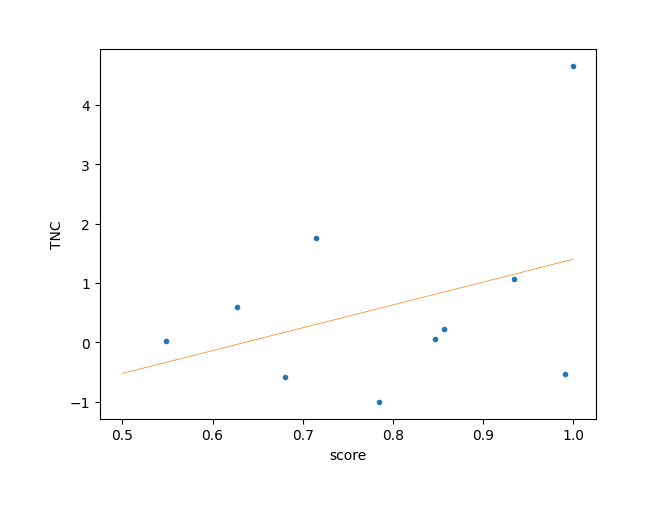

In [17]:
ligand = "TNC"
lm = LinearRegression().fit(
    res.reshape(-1, 1),
    np.array(combined[ligand]).reshape(-1, 1)
)
plt.xlabel("score")
plt.ylabel(ligand)
plt.plot(combined["score"], combined[ligand], "o")
xs = np.array((0.5, 1)).reshape(-1, 1)
ys = lm.predict(xs)
plt.plot(xs, ys)
plt.show()

In [16]:
session_info.show()